In [81]:
print('ciao mondo')

ciao mondo


In [96]:
import pandas as pd  #mi importo la liberia pandas
from sklearn.tree import DecisionTreeRegressor #mi importo una parte della libreria DecisionTreeRegressor 
from sklearn.model_selection import train_test_split #che divide un dataset in due parti: una per l'addestramento del modello (training set) e una per la valutazione del modello (test set)*.
from sklearn.metrics import accuracy_score #che calcola l'accuratezza di un modello

df = pd.read_csv('vgsales.csv') #read_csv mi fa leggere il file csv
df.shape #mi stampa quandi righe e colonne e formanìto


(16598, 11)

In [83]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [84]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [85]:
df.values #mi stampa solo i valori 

array([[1, 'Wii Sports', 'Wii', ..., 3.77, 8.46, 82.74],
       [2, 'Super Mario Bros.', 'NES', ..., 6.81, 0.77, 40.24],
       [3, 'Mario Kart Wii', 'Wii', ..., 3.79, 3.31, 35.82],
       ...,
       [16598, 'SCORE International Baja 1000: The Official Game', 'PS2',
        ..., 0.0, 0.0, 0.01],
       [16599, 'Know How 2', 'DS', ..., 0.0, 0.0, 0.01],
       [16600, 'Spirits & Spells', 'GBA', ..., 0.0, 0.0, 0.01]],
      shape=(16598, 11), dtype=object)

In [86]:
X = df.drop(columns=['Name','Genre','Platform','Publisher',], axis=1) #mi cancella una colonna 
X

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...
16593,16596,2002.0,0.01,0.00,0.00,0.00,0.01
16594,16597,2003.0,0.01,0.00,0.00,0.00,0.01
16595,16598,2008.0,0.00,0.00,0.00,0.00,0.01
16596,16599,2010.0,0.00,0.01,0.00,0.00,0.01


In [87]:
X.head()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,2006.0,41.49,29.02,3.77,8.46,82.74
1,2,1985.0,29.08,3.58,6.81,0.77,40.24
2,3,2008.0,15.85,12.88,3.79,3.31,35.82
3,4,2009.0,15.75,11.01,3.28,2.96,33.00
4,5,1996.0,11.27,8.89,10.22,1.00,31.37


In [88]:
y = df['JP_Sales']
y

0         3.77
1         6.81
2         3.79
3         3.28
4        10.22
         ...  
16593     0.00
16594     0.00
16595     0.00
16596     0.00
16597     0.00
Name: JP_Sales, Length: 16598, dtype: float64

In [89]:
#divide il dataset x e y in due parti: una per l'addestramento del 
#modello (x_train e y_train) e una per la valutazione del modello 
#(x_test e y_test), con il 20% dei dati assegnati al test set
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [90]:
X_train

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
4282,4284,2006.0,0.09,0.24,0.00,0.12,0.46
11365,11367,2009.0,0.04,0.03,0.00,0.01,0.08
10056,10058,2009.0,0.11,0.00,0.00,0.01,0.11
15930,15933,2015.0,0.00,0.00,0.02,0.00,0.02
10061,10063,2010.0,0.10,0.00,0.00,0.01,0.11
...,...,...,...,...,...,...,...
13075,13077,2015.0,0.00,0.00,0.05,0.00,0.05
9242,9244,2011.0,0.00,0.00,0.14,0.00,0.14
13522,13524,2008.0,0.00,0.00,0.04,0.00,0.04
10440,10442,2003.0,0.05,0.04,0.00,0.01,0.10


In [91]:
model = DecisionTreeRegressor() # crea un modello di regressione ad albero di decisione
model.fit(X_train, y_train) #addestra il modello sui dati x e y per imparare a prevedere la variabile target.

predictions = model.predict(X_test) #utilizza il modello addestrato per fare previsioni sui nuovi dati
predictions

array([0.05, 0.06, 0.  , ..., 0.03, 0.  , 0.12], shape=(3320,))

In [92]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

iniziare da qui per liner regression

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [11]:
# Creiamo un semplice dataset di esempio
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 5, 4, 5])

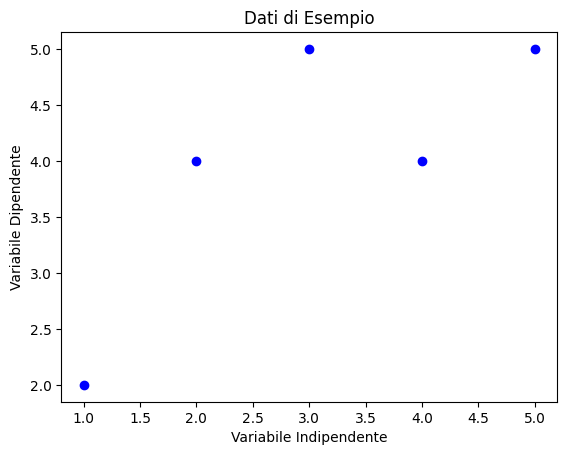

In [12]:
# Visualizziamo i dati
plt.scatter(X, y, color='blue')
plt.xlabel('Variabile Indipendente')
plt.ylabel('Variabile Dipendente')
plt.title('Dati di Esempio')
plt.show()

In [13]:
# Inizializziamo il modello di regressione lineare
model = LinearRegression()

# Addestriamo il modello sui dati
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Otteniamo l'intercetta e il coefficiente angolare
intercept = model.intercept_
coefficient = model.coef_[0]

print(f'Intercetta (β₀): {intercept}')
print(f'Coefficiente Angolare (β₁): {coefficient}')

Intercetta (β₀): 2.2
Coefficiente Angolare (β₁): 0.6


In [16]:
# Facciamo previsioni sui dati di input
y_pred = model.predict(X)
y_pred

array([2.8, 3.4, 4. , 4.6, 5.2])

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

# Calcoliamo l'errore quadratico medio e 
# il coefficiente di determinazione
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'Errore Quadratico Medio (MSE): {mse}')
print(f'Coefficiente di Determinazione (R²): {r2}')

Errore Quadratico Medio (MSE): 0.47999999999999987
Coefficiente di Determinazione (R²): 0.6000000000000001


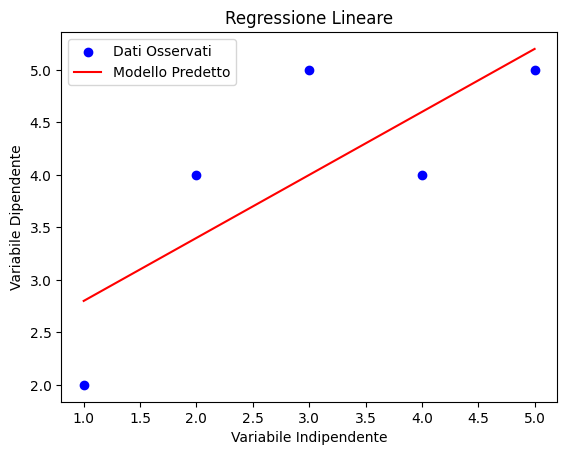

In [18]:
# Visualizziamo i risultati
plt.scatter(X, y, color='blue', label='Dati Osservati')
plt.plot(X, y_pred, color='red', label='Modello Predetto')
plt.xlabel('Variabile Indipendente')
plt.ylabel('Variabile Dipendente')
plt.title('Regressione Lineare')
plt.legend()
plt.show()

In [19]:
# Dataset con due variabili indipendenti
X_multi = np.array([[1, 2],
                    [2, 1],
                    [3, 0],
                    [4, -1],
                    [5, -2]])
y_multi = np.array([5, 4, 6, 8, 7])

# Inizializziamo e addestriamo il modello
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

# Otteniamo i coefficienti
intercept_multi = model_multi.intercept_
coefficients_multi = model_multi.coef_

print(f'Intercetta (β₀): {intercept_multi}')
print(f'Coefficiente β₁: {coefficients_multi[0]}')
print(f'Coefficiente β₂: {coefficients_multi[1]}')


Intercetta (β₀): 4.8
Coefficiente β₁: 0.4000000000000001
Coefficiente β₂: -0.4


In [20]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [21]:
# Caricamento del dataset
housing = fetch_california_housing(as_frame=True)
data = housing.frame
target = housing.target

In [22]:
print(housing)

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -1

In [23]:
print(data)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

In [24]:
print(target)

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


In [31]:
# Visualizzazione delle prime righe del dataset e delle sue colonne
print("Prime 5 righe del dataset:")
print(data.head())

Prime 5 righe del dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [32]:
print("\nInformazioni sulle colonne del dataset:")
print(data.info())


Informazioni sulle colonne del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [30]:
print("\nDescrizione delle statistiche del dataset:")
print(data.describe())


Descrizione delle statistiche del dataset:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532     

In [34]:
# Aggiungiamo la variabile target al DataFrame 
# per facilitare l'analisi delle correlazioni
data['MedHouseVal'] = target
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [35]:
# Matrice di correlazione per vedere la 
# relazione tra le variabili
print("\nMatrice di correlazione:")
print(data.corr()['MedHouseVal'].sort_values(ascending=False))


Matrice di correlazione:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


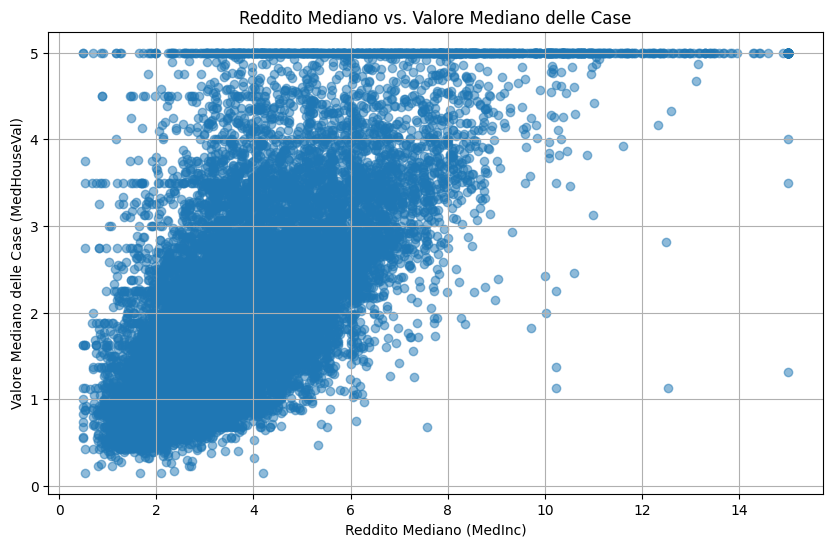

In [36]:
# Visualizzazione della relazione tra una variabile 
# indipendente e la variabile target
# Ad esempio, Useremo 'MedInc' (reddito mediano) che ha una 
# forte correlazione positiva
plt.figure(figsize=(10, 6))
plt.scatter(data['MedInc'], data['MedHouseVal'], alpha=0.5)
plt.title('Reddito Mediano vs. Valore Mediano delle Case')
plt.xlabel('Reddito Mediano (MedInc)')
plt.ylabel('Valore Mediano delle Case (MedHouseVal)')
plt.grid(True)
plt.show()

In [37]:
# Definiamo le variabili indipendenti (X) e dipendenti (y)
X = data.drop('MedHouseVal', axis=1) # Tutte le colonne tranne 'MedHouseVal'
y = data['MedHouseVal'] # La colonna 'MedHouseVal'


In [38]:
# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
print(f"\nDimensione del set di training: {X_train.shape[0]} samples")
print(f"Dimensione del set di test: {X_test.shape[0]} samples")


Dimensione del set di training: 16512 samples
Dimensione del set di test: 4128 samples


In [40]:
# Creazione del modello di regressione lineare
model = LinearRegression()

In [41]:
# Addestramento del modello sul set di training
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# Visualizzazione dei coefficienti e dell'intercetta
print("\nCoefficienti del modello (m_i):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"\nIntercetta del modello (b): {model.intercept_:.4f}")



Coefficienti del modello (m_i):
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337

Intercetta del modello (b): -37.0233


In [44]:
# Effettuare predizioni sul set di test
y_pred = model.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

In [47]:
# Calcolo delle metriche di valutazione
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R-squared (R²): 0.5758


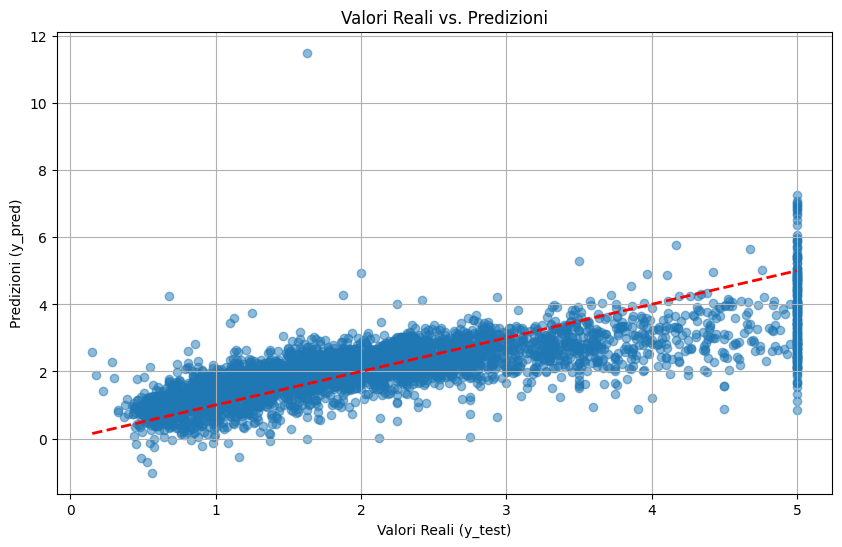

In [48]:
# Visualizzazione delle predizioni vs. valori reali
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Linea y=x
plt.title('Valori Reali vs. Predizioni')
plt.xlabel('Valori Reali (y_test)')
plt.ylabel('Predizioni (y_pred)')
plt.grid(True)
plt.show()

logistc regression

In [1]:
!pip install pandas scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\Roman\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
#importo questi liberie
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Caricamento del dataset Iris
iris = load_iris(as_frame=True)
data = iris.frame
target_names = iris.target_names

In [4]:
# Per la regressione logistica binaria, selezioniamo solo 
# due classi
# Ad esempio, classifichiamo 'setosa' (0) vs 'versicolor' 
# (1) e rimuoviamo 'virginica' (2)
data_binary = data[data['target'] != 2]
X = data_binary.drop('target', axis=1)
y = data_binary['target']


In [5]:
# Visualizzazione delle prime righe del dataset 
# binario e delle sue colonne
print("Prime 5 righe del dataset Iris (binario):")
print(data_binary.head())
print(f"\nClassi utilizzate: {target_names[0]} (0) e {target_names[1]} (1)")
print("\nDistribuzione delle classi:")
print(y.value_counts())

Prime 5 righe del dataset Iris (binario):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Classi utilizzate: setosa (0) e versicolor (1)

Distribuzione delle classi:
target
0    50
1    50
Name: count, dtype: int64


In [6]:
# Analisi delle correlazioni (opzionale, ma 
# utile per capire le relazioni)
print("\nMatrice di correlazione:")
print(data_binary.corr()['target'].sort_values(ascending=False))



Matrice di correlazione:
target               1.000000
petal length (cm)    0.969990
petal width (cm)     0.960307
sepal length (cm)    0.728290
sepal width (cm)    -0.690684
Name: target, dtype: float64


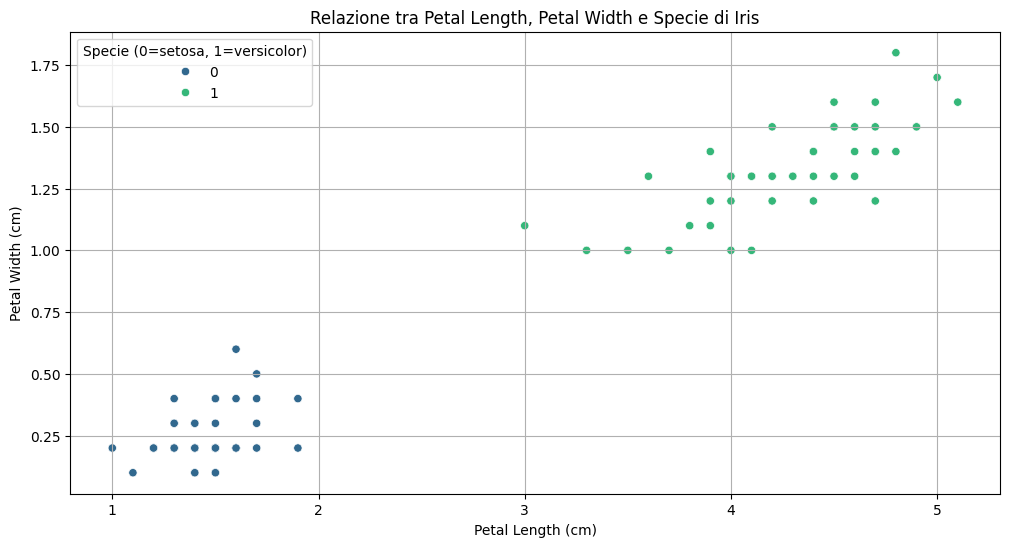

In [7]:
# Visualizzazione della relazione tra le feature e il target
# Useremo 'petal length (cm)' e 'petal width (cm)' in 
# quanto sono spesso discriminanti per Iris
plt.figure(figsize=(12, 6))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='target', data=data_binary, palette='viridis')
plt.title('Relazione tra Petal Length, Petal Width e Specie di Iris')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Specie (0=setosa, 1=versicolor)')
plt.grid(True)
plt.show()

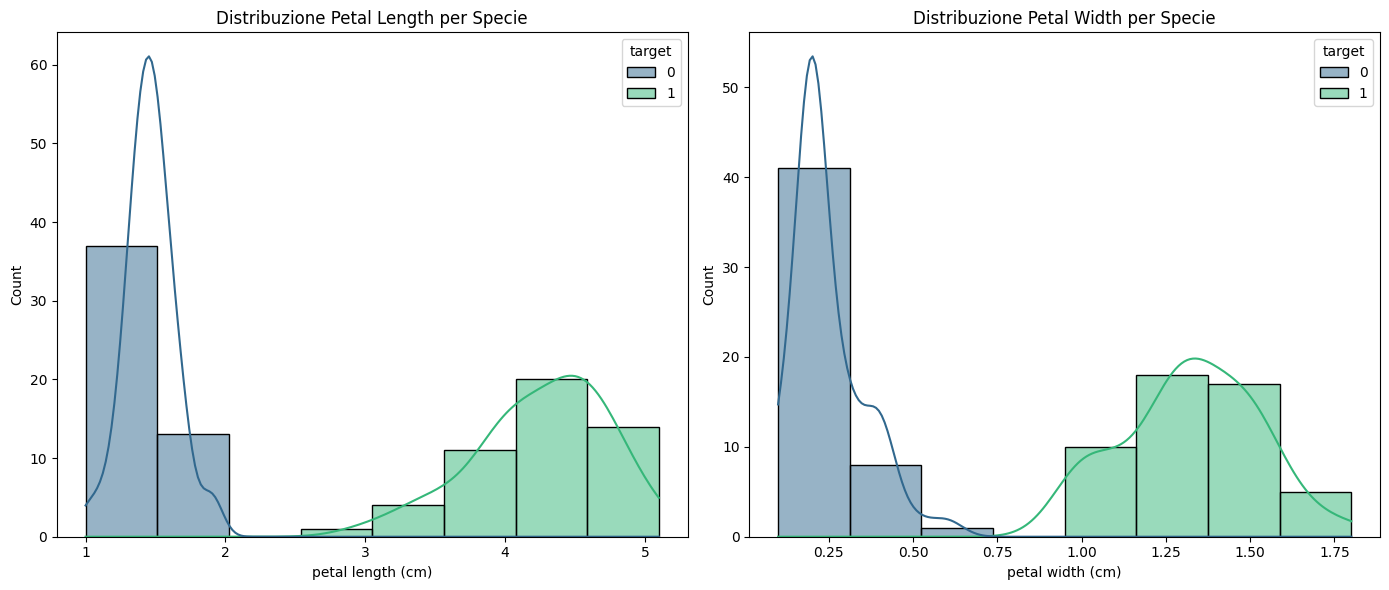

In [8]:
# Distribuzione delle singole features per classe
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data=data_binary, x='petal length (cm)', hue='target', kde=True, ax=axes[0], palette='viridis')
axes[0].set_title('Distribuzione Petal Length per Specie')
sns.histplot(data=data_binary, x='petal width (cm)', hue='target', kde=True, ax=axes[1], palette='viridis')
axes[1].set_title('Distribuzione Petal Width per Specie')
plt.tight_layout()
plt.show()

In [9]:
# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [10]:
print(f"\nDimensione del set di training: {X_train.shape[0]} samples")
print(f"Dimensione del set di test: {X_test.shape[0]} samples")
print(f"Distribuzione delle classi nel training set:\n{y_train.value_counts()}")
print(f"Distribuzione delle classi nel test set:\n{y_test.value_counts()}")


Dimensione del set di training: 75 samples
Dimensione del set di test: 25 samples
Distribuzione delle classi nel training set:
target
1    38
0    37
Name: count, dtype: int64
Distribuzione delle classi nel test set:
target
0    13
1    12
Name: count, dtype: int64


In [11]:
# Creazione del modello di regressione logistica
# max_iter è aumentato per garantire la convergenza 
# per alcuni dataset
model = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)


In [12]:
# Addestramento del modello sul set di training
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'deprecated'


In [13]:
# Visualizzazione dei coefficienti e dell'intercetta
print("\nCoefficienti del modello (beta_i):")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")
print(f"\nIntercetta del modello (beta_0): {model.intercept_[0]:.4f}")


Coefficienti del modello (beta_i):
sepal length (cm): -0.3191
sepal width (cm): -1.4320
petal length (cm): 2.0611
petal width (cm): 0.9362

Intercetta del modello (beta_0): -0.2449


In [14]:
# Effettuare predizioni sul set di test
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probabilità della classe positiva


In [15]:
# Calcolo delle metriche di valutazione
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=[target_names[0], target_names[1]])


In [16]:
print(f"\nAccuratezza del modello: {accuracy:.4f}")
print("\nMatrice di Confusione:\n", conf_matrix)
print("\nReport di Classificazione:\n", class_report)


Accuratezza del modello: 1.0000

Matrice di Confusione:
 [[13  0]
 [ 0 12]]

Report di Classificazione:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



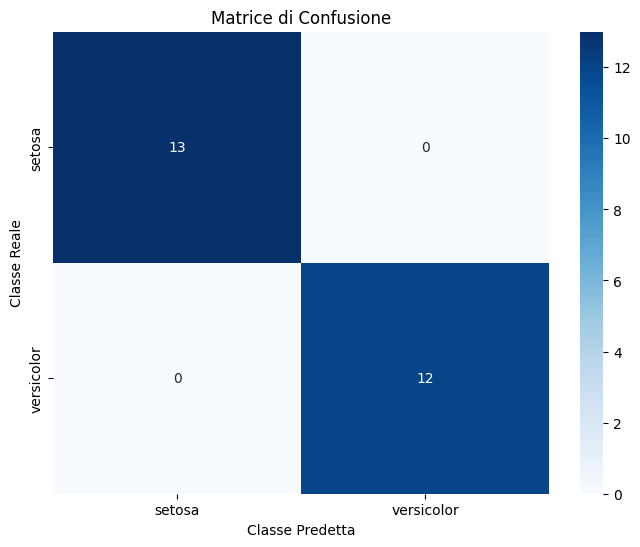

In [17]:
# Visualizzazione della Matrice di Confusione
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[target_names[0], target_names[1]],
            yticklabels=[target_names[0], target_names[1]])
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.title('Matrice di Confusione')
plt.show()

In [18]:
# Curva ROC (Receiver Operating Characteristic) - 
# utile per problemi di classificazione binaria
from sklearn.metrics import roc_curve, roc_auc_score

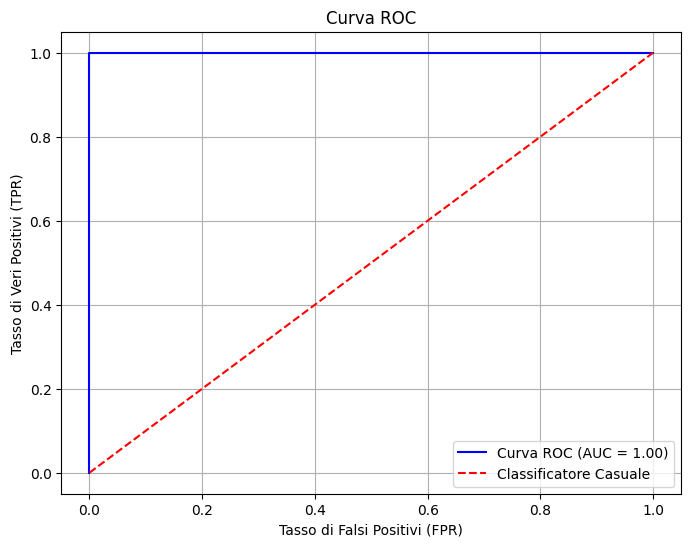

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificatore Casuale')
plt.xlabel('Tasso di Falsi Positivi (FPR)')
plt.ylabel('Tasso di Veri Positivi (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

Ingegneria delle carateristiche


In [41]:
#Iniziamo con un dataset di esempio che include il prezzo, le stanze e il quartiere delle case.
import pandas as pd

data = [
    {'price': 850000, 'rooms': 4, 'neighborhood': 'Queen Anne'},
    {'price': 700000, 'rooms': 3, 'neighborhood': 'Fremont'},
    {'price': 650000, 'rooms': 3, 'neighborhood': 'Wallingford'},
    {'price': 600000, 'rooms': 2, 'neighborhood': 'Fremont'}
]

df = pd.DataFrame(data)
print(df)

    price  rooms neighborhood
0  850000      4   Queen Anne
1  700000      3      Fremont
2  650000      3  Wallingford
3  600000      2      Fremont


In [42]:
#Si potrebbe essere tentati di codificare i dati categorici 
#con una semplice mappatura numerica. Il LabelEncoder di 
#Scikit-Learn può convertire le stringhe 
#(o etichette categoriche) in valori numerici.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x_encoded = le.fit_transform(df["neighborhood"])
print(x_encoded)

[1 0 2 0]


In [43]:
#Una tecnica efficace è l'One-Hot Encoding. 
#Questa tecnica crea colonne aggiuntive che indicano 
#la presenza (1) o l'assenza (0) di una categoria. 
#Quando i dati sono in un elenco di dizionari, DictVectorizer 
#di Scikit-Learn può trasformarli in vettori.
from sklearn.feature_extraction import DictVectorizer

vec = DictVectorizer(sparse=False, dtype=int)
transformed_data = vec.fit_transform(data)
print(transformed_data)

[[     0      1      0 850000      4]
 [     1      0      0 700000      3]
 [     0      0      1 650000      3]
 [     1      0      0 600000      2]]


In [44]:
#Per capire il significato di ciascuna colonna, 
#possiamo controllare i nomi delle caratteristiche:
print(vec.get_feature_names_out())


['neighborhood=Fremont' 'neighborhood=Queen Anne'
 'neighborhood=Wallingford' 'price' 'rooms']


In [45]:
#Un potenziale svantaggio di questo approccio è che se 
#la categoria ha molti valori possibili, la dimensione del 
#dataset può aumentare notevolmente. Tuttavia, poiché 
#i dati codificati contengono principalmente zeri, 
# un output sparso può essere molto efficiente.
vec = DictVectorizer(sparse=True, dtype=int)
X = vec.fit_transform(data)
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (4, 5)>
  Coords	Values
  (0, 1)	1
  (0, 3)	850000
  (0, 4)	4
  (1, 0)	1
  (1, 3)	700000
  (1, 4)	3
  (2, 2)	1
  (2, 3)	650000
  (2, 4)	3
  (3, 0)	1
  (3, 3)	600000
  (3, 4)	2


In [46]:
#Possiamo visualizzare 
#questa matrice sparsa correttamente usando Pandas:
import pandas as pd
pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

,neighborhood=Fremont,neighborhood=Queen Anne,neighborhood=Wallingford,price,rooms
0,0,1,0,850000,4
1,1,0,0,700000,3
2,0,0,1,650000,3
3,1,0,0,600000,2


In [47]:
#Un altro strumento per il One-Hot Encoding 
#è sklearn.preprocessing.OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

x=[["casa","no"],["non casa","si"],["casa","no"],["non casa","si"]]
y =[0,1,0,1]

X = pd.DataFrame(x)
y = pd.Series(y)
print(X, y)

# Preprocessing: encoder per colonna categorica
one_hot = OneHotEncoder(sparse_output=False)
X = one_hot.fit_transform(X)
print(X)


          0   1
0      casa  no
1  non casa  si
2      casa  no
3  non casa  si 0    0
1    1
2    0
3    1
dtype: int64
[[1. 0. 1. 0.]
 [0. 1. 0. 1.]
 [1. 0. 1. 0.]
 [0. 1. 0. 1.]]


come funziona Scikit-Learn per un problema di regressione lineare.